In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapillondhe/american-sign-language")

print("Path to dataset files:", path)

100%|██████████| 4.64G/4.64G [04:36<00:00, 18.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kapillondhe/american-sign-language/versions/1


In [2]:
import os
import numpy as np
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

In [3]:
def load_images(folder_path, img_size=64, max_per_class=100):
    images = []
    labels = []

    for class_name in sorted(os.listdir(folder_path)):
        class_path = os.path.join(folder_path, class_name)

        if not os.path.isdir(class_path):
            continue

        count = 0
        for img_name in os.listdir(class_path):
            if count >= max_per_class:
                break

            img_path = os.path.join(class_path, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

            img = cv2.bitwise_and(img, img, mask=mask)

            img = cv2.resize(img, (img_size, img_size))
            img = img / 255.0

            images.append(img)
            labels.append(class_name)
            count += 1

    return np.array(images), np.array(labels)

In [5]:
train_path = os.path.join(path, "ASL_Dataset/Train")
test_path  = os.path.join(path, "ASL_Dataset/Test")

print("Loading train")
X_train, y_train = load_images(train_path, max_per_class=1000)

print("Loading test")
X_test, y_test   = load_images(test_path, max_per_class=500)

print(f"\nTrain: {X_train.shape} | Labels: {y_train.shape}")
print(f"Test:  {X_test.shape}  | Labels: {y_test.shape}")

Loading train
Loading test

Train: (28000, 64, 64) | Labels: (28000,)
Test:  (112, 64, 64)  | Labels: (112,)


In [6]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print(f"Classes ({len(le.classes_)}): {le.classes_}")

Classes (28): ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'Nothing' 'O' 'P'
 'Q' 'R' 'S' 'Space' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']


In [7]:

X_train_ml = X_train.reshape(len(X_train), -1)
X_test_ml  = X_test.reshape(len(X_test), -1)


X_train_dl = X_train.reshape(-1, 64, 64, 1)
X_test_dl  = X_test.reshape(-1, 64, 64, 1)

print(f"ML shape → X_train: {X_train_ml.shape}")
print(f"DL shape → X_train: {X_train_dl.shape}")

ML shape → X_train: (28000, 4096)
DL shape → X_train: (28000, 64, 64, 1)


In [8]:
X_train_ml, y_train_ml = shuffle(X_train_ml, y_train_encoded, random_state=42)
X_train_dl, y_train_dl = shuffle(X_train_dl, y_train_encoded, random_state=42)

print("Shuffle done")

Shuffle done


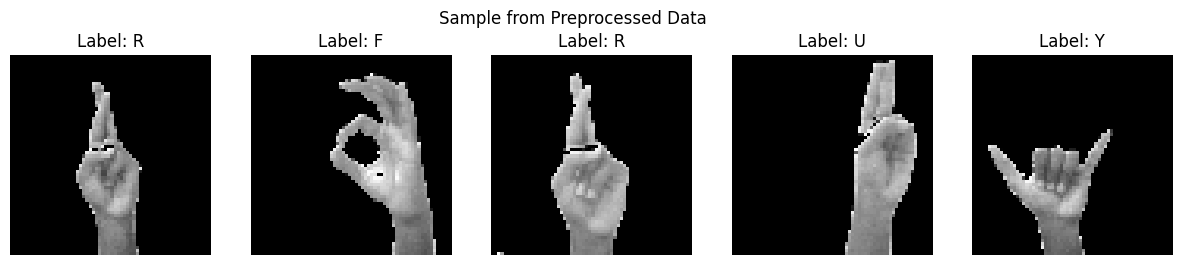

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_train_dl[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Label: {le.classes_[y_train_dl[i]]}")
    ax.axis('off')

plt.suptitle("Sample from Preprocessed Data")
plt.show()

In [10]:
# ===== CNN MODEL =====
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


In [23]:
y_train_cat_shuffled = to_categorical(y_train_dl, num_classes=num_classes)
y_test_cat = to_categorical(y_test_encoded, num_classes=num_classes)

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_dl,
    y_train_cat_shuffled,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_dl
)

print('Aligned Train shape:', X_train_cnn.shape, y_train_cnn.shape)
print('Aligned Val shape:  ', X_val_cnn.shape, y_val_cnn.shape)

Aligned Train shape: (23800, 64, 64, 1) (23800, 28)
Aligned Val shape:   (4200, 64, 64, 1) (4200, 28)


In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest'
)

# Fit the generator to the training data
datagen.fit(X_train_cnn)
print('Data augmentation generator ready.')

Data augmentation generator ready.


In [42]:
cnn_model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.40),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_35 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 28)             │         7,196 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,244,348 (8.56 MB)

 Trainable params: 2,243,900 (8.56 MB)

 Non-trainable params: 448 (1.75 KB)

In [44]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9905 - loss: 0.0274 - val_accuracy: 0.9962 - val_loss: 0.0134
Epoch 2/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9908 - loss: 0.0261 - val_accuracy: 0.9990 - val_loss: 0.0026
Epoch 3/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9913 - loss: 0.0260 - val_accuracy: 0.9998 - val_loss: 7.6381e-04
Epoch 4/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9931 - loss: 0.0217 - val_accuracy: 0.9945 - val_loss: 0.0179
Epoch 5/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9935 - loss: 0.0187 - val_accuracy: 0.9900 - val_loss: 0.0422
Epoch 6/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9939 - loss: 0.0191 - val_accuracy: 0.9998 - val_loss: 2.8770e-04
Epoch 7/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9947 - loss: 0.0156 - val_accuracy: 0.9976 - val_loss: 0.0061
Epoch 8/15
744/744 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9947 - loss: 0.0159 - 

In [45]:
test_loss, test_acc = cnn_model.evaluate(X_test_dl, y_test_cat, verbose=0)
print(f'CNN Test Loss: {test_loss:.4f}')
print(f'CNN Test Accuracy: {test_acc:.4f}')

y_pred_probs = cnn_model.predict(X_test_dl, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_encoded

print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=le.classes_))


CNN Test Loss: 0.0000
CNN Test Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         4
           B       1.00      1.00      1.00         4
           C       1.00      1.00      1.00         4
           D       1.00      1.00      1.00         4
           E       1.00      1.00      1.00         4
           F       1.00      1.00      1.00         4
           G       1.00      1.00      1.00         4
           H       1.00      1.00      1.00         4
           I       1.00      1.00      1.00         4
           J       1.00      1.00      1.00         4
           K       1.00      1.00      1.00         4
           L       1.00      1.00      1.00         4
           M       1.00      1.00      1.00         4
           N       1.00      1.00      1.00         4
     Nothing       1.00      1.00      1.00         4
           O       1.00      1.00      1.00         4
          

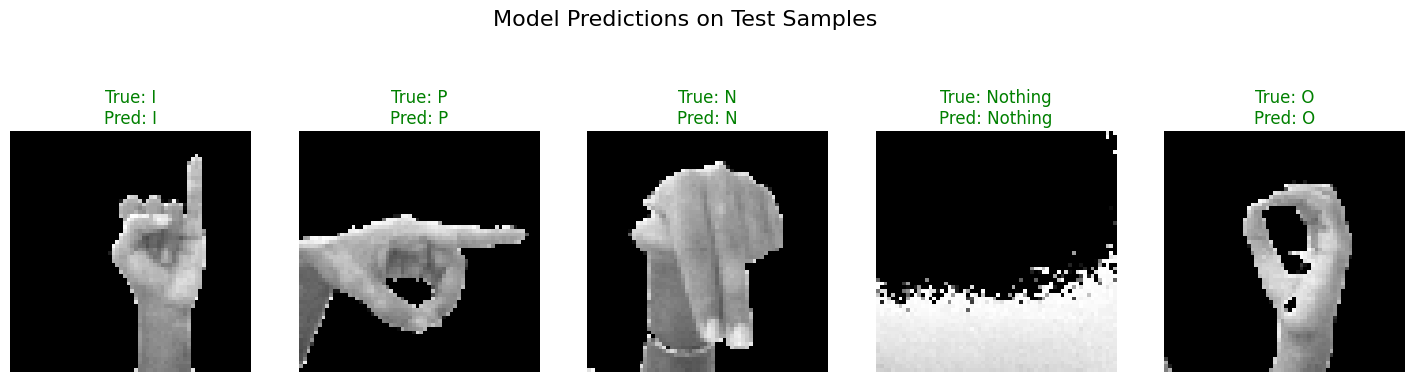

In [29]:
import random

# Select 5 random indices from the test set
sample_indices = random.sample(range(len(X_test_dl)), 5)

plt.figure(figsize=(18, 5))

for i, idx in enumerate(sample_indices):
    img = X_test_dl[idx]
    true_label = le.classes_[y_test_encoded[idx]]

    # Predict
    pred_probs = cnn_model.predict(img.reshape(1, 64, 64, 1), verbose=0)
    pred_label = le.classes_[np.argmax(pred_probs)]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img.reshape(64, 64), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis('off')

plt.suptitle("Model Predictions on Test Samples", fontsize=16)
plt.show()

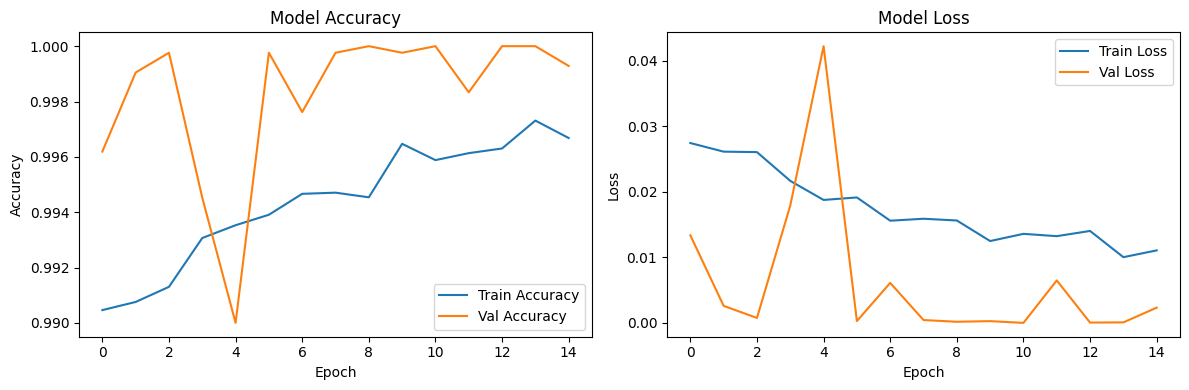

In [47]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()